#**Actividad 2**

###**Maestría en Inteligencia Artificial Aplicada**
###**Curso: Inteligencia Artificial y Aprendizaje Automático**
####**Tecnológico de Monterrey**
#####**Prof Luis Eduardo Falcón Morales**

###**Nombre del estudiante: Darío Martín Romero Cruz**

###**Matrícula: A01841015**

**NOTAS:**

*   Esta actividad la puedes realizar en Google-Colab.
*   Usaremos un conjunto de datos bastante conocido, llamado California_Housing o California_Housing_Prices. El objetivo en este caso es predecir el costo mediano de una casa en el estado de California, a partir de la información que se proporciona de la misma.
* Esta base de datos es muy conocida y a lo largo de los años ha sufrido muchas modificaciones, pero todas ellas siguen siendo utilizadas para su análisis.
*   En particular, en esta actividad usaremos los datos del archivo llamado california_housing_train.csv que se encuentra en la carpeta **sample_data**, en la sección de **Archivos** del Google-Colab que se encuentra en el menú ubicado a la izquierda.
* La información sobre el significado de las variables la puedes encontrar en la siguiente liga de Kaggle. Sin embargo, cabe mencionar que estrictamente los datos son diferentes a los del Google-Colab, por lo que solamente utiliza esta liga para obtener el significado de las variables: https://www.kaggle.com/datasets/camnugent/california-housing-prices

* Mencionamos también que el archivo california_housing_train.csv ya representa al conjunto de entrenamiento, por lo que no hace falta hacer una partición adicional para los análisis que estaremos haciendo.
*   Por otro lado, no es necesario trabajar con Google-Colab, puedes cargar y trabajar los datos en el entorno de desarrollo integrado (IDE) de tu preferencia.
* En esta actividad el código en Python ya está dado y no es necesario agregar más código. Sin embargo, si deseas incluir algún código adicional para justificar alguna de tus respuestas, lo puedes hacer, pero debes agregarlo en una nueva celda de código y no modificar en absoluto el código que ya está dado.
* Para responder a las preguntas de esta actividad, puedes apoyarte en alguna bibliografía del tema, o bien, mediante el uso de alguno de los llamados Modelos de Gran Tamaño, LLM, por sus siglas en inglés Large Language Model.
* Cuando utilices uno o varios LLM para responder una pregunta, deberás indicar cuál fue o fueron los utilizados. Por ejemplo, chatGPT, Copilot, Gemini, Claude, etc. De hecho, durante el presente curso nos estaremos apoyando constantemente en los modelos LLM.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import power_transform


In [2]:
# Si estás ejecutando este cuaderno de Jupyter desde Google Colab, podemos
# cargar el archivo desde la siguiente carpeta:
##DIR = "/content/sample_data/"
##os.chdir(DIR)

# Una vez cargado los datos de entrenamiento, obtenemos una descripción de cada variable:
misdatos = pd.read_csv("california_housing_train.csv", sep=",")
print("Dimensión del conjunto de entrenamiento:", misdatos.shape)
misdatos.describe()

Dimensión del conjunto de entrenamiento: (17000, 9)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000,17000.000000
mean,-119.562108,35.625225,28.589353,2643.664412,539.410824,1429.573941,501.221941,3.883578,207300.912353
std,2.005166,2.137340,12.586937,2179.947071,421.499452,1147.852959,384.520841,1.908157,115983.764387
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.790000,33.930000,18.000000,1462.000000,297.000000,790.000000,282.000000,2.566375,119400.000000
50%,-118.490000,34.250000,29.000000,2127.000000,434.000000,1167.000000,409.000000,3.544600,180400.000000
75%,-118.000000,37.720000,37.000000,3151.250000,648.250000,1721.000000,605.250000,4.767000,265000.000000
max,-114.310000,41.950000,52.000000,37937.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


# **Ejercicio 1 : Transformación de Variables**

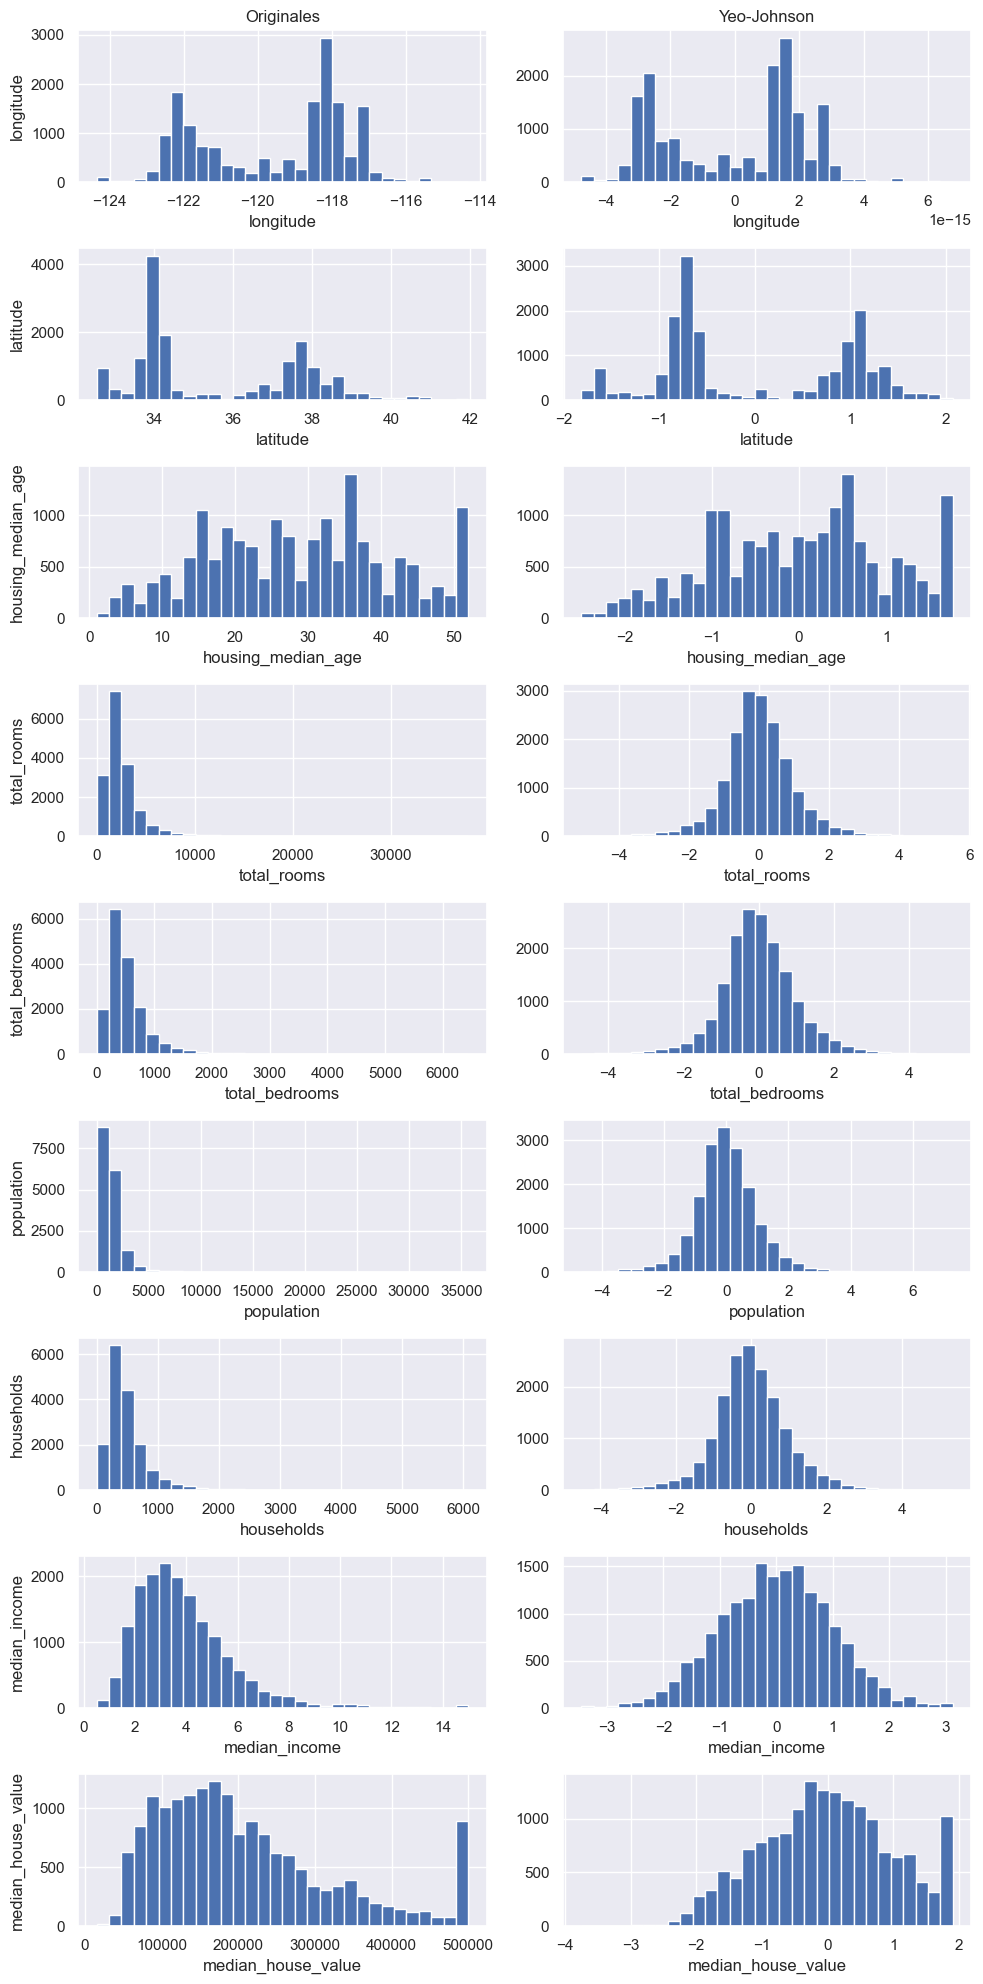

In [3]:
# NO DEBES MODIFICAR EL CóDIGO DE ESTA CELDA:

# Obtengamos los siguientes histogramas de los datos originales y sus transformaciones indicadas:

# Lista de las variables a transformar:
variables_a_transformar = ['longitude','latitude','housing_median_age','total_rooms',
                           'total_bedrooms','population','households','median_income',
                           'median_house_value']

yj = []  # para guardar las transformaciones obtenidas y usarlas más adelante con Pearson.

# Configuramos el entorno gráfico y mostramos los histogramas originales y los transformados:
sns.set(rc={'figure.figsize':(10,20)})
fig, axes = plt.subplots(len(variables_a_transformar),2)

for k in range(0, len(variables_a_transformar)):

    # Datos originales:
    Transf_originales = misdatos[variables_a_transformar[k]]

    plt.subplot(len(variables_a_transformar), 2, 2 * k + 1)
    plt.hist(Transf_originales, bins=30)
    plt.xlabel(variables_a_transformar[k])
    if k == 0:
        plt.title('Originales')
    plt.ylabel(variables_a_transformar[k]) # Esta es la etiqueta de cada variable.


    # Datos transformados con Yeo-Johnson:
    # La transformación .to_numpy().reshape(-1,1) es porque power_transform espera una entrada 2D
    Transf_yeojohnson = power_transform((Transf_originales.to_numpy()).reshape(-1,1), method ='yeo-johnson')
    yj.append(Transf_yeojohnson)

    plt.subplot(len(variables_a_transformar), 2, 2 * k + 2)
    plt.hist(Transf_yeojohnson, bins=30)
    plt.xlabel(variables_a_transformar[k])
    if k == 0:
        plt.title('Yeo-Johnson')

plt.tight_layout()
plt.show()

**Observa que las variables de entrada total_rooms, total_bedrooms, population y households, están claramente sesgadas positivamente. Y la variable de entrada median_income y la de salida median_house_value, un poco menos sesgadas.**



**PREGUNTAS:**

En los siguientes ejercicios supongamos que estamos analizando y preparando los datos para aplicar posteriormente un modelo de regresión lineal múltiple.

*   **Pregunta 1.1.** ¿Para qué se aplica usualmente la transformación Yeo-Johnson y cuál es su diferencia con Box-Cox?

*   **Pregunta 1.2.** ¿Cuál es la diferencia entre utilizar la métrica de la raíz cuadrada del error cuadrático medio RMSE (Root Mean Squared Error) y la del error absoluto medio MAE (Mean Absolute Error)? ¿Cuándo se recomienda utilizar cada uno?

*   **Pregunta 1.3.** Si vamos a aplicar posteriormente el modelo de regresión lineal múltiple y habiendo observado de los histogramas que las variables de entrada total_rooms, total_bedrooms, population, households y median_income tienen sesgos positivos ¿es recomendable aplicar alguna transformación de corrección de sesgo, como la mostrada de Yeo-Johnson en dichas variables? ¿Por qué?

*   **Pregunta 1.4.** Considerando ahora todas las variables de entrada de este problema, ¿es recomendable aplicarles alguna transformación de ajuste de escala (por ejemplo, la min-max, o la de normalización) antes de aplicar el modelo de regresión lineal múltiple? ¿Por qué?

*   **Pregunta 1.5.** Supongamos que ya decidiste aplicar la transformación Yeo-Johnson a las varibles sesgadas identificadas previamente. Una vez aplicada la Yeo-Johnson, ¿también es válido o recomendable aplicarles ahora una transformación de escala? ¿Por qué? En particular observa los histogramas resultantes con Yeo-Johnson obtenidos anteriormente para respaldar tu respuesta.

*   **Pregunta 1.6.** Supongamos que por alguna razón ya decidiste aplicar a las variables sesgadas tanto la transformación Yeo-Johnson, como la transformación de escala, ¿sería lo mismo aplicar primero la Yeo-Johnson seguida de la transformación de escala, que si lo hiciéramos al revés, es decir, primero la transformación de escala y luego la Yeo-Johnson? Justifica tu respuesta.

*   **Pregunta 1.7.** Observa ahora los histogramas de las variables de entrada originales "longitude" y "latitude". Claramente podríamos considerar a dichos histogramas como gráficos bimodales. ¿Qué se recomienda hacer en este caso? Es decir, ¿qué tipo de transformación o transformaciones se recomiendan aplicar? En particular, en este caso se observa que para estas variables la Yeo-Johnson no ayudó en absoluto.


*   **Pregunta 1.8.** Analicemos ahora la variable de salida median_house_value. ¿Cuál es ahora la recomendación para ajustar o transformar el sesgo o de corrección de escala? ¿Serían exactamente las mismas recomendaciones que se hicieron para las variables de entrada o se aplicaría un criterio diferente? Justifica tu respuesta.

*   **Pregunta 1.9.** Observa ahora el histograma de la variable de salida "median_house_value", ya sea la original o la transformada. Claramente se observa un "pico" al final de cualquiera de estos histogramas. ¿Qué transformación, criterio o recomendación adicional aplicaría para este tipo de gráficos?

### **Respuestas:**


++++++++ Inicia sección para agregar texto ++++++++++++++++++++++++++


*   **Respuesta 1.1.** La transformación de Yeo-Johnson sirve para llevar la distribución de nuestra variable a una forma más simétrica (idealmente gaussiana), reduciendo así su sesgo. También es efectiva para el manejo de outliers, ya que mejora el comportamiento de la cola. Para el caso de nuestro ejercicio, en las variables claramente sesgadas sí pareció dar un resultado efectivo. La diferencia contra una transformación de Box-Cox es que esta última no es útil para variables con valores no positivos, por ejemplo, la longitud en este ejercicio.

*   **Respuesta 1.2.** Ambas son métricas generadas a partir de los residuos de nuestro modelo. Sin embargo, el RMSE, al elevar los residuos al cuadrado, da un mayor castigo a los errores grandes, por lo que se recomienda en ciertos contextos donde la precisión es muy importante y los errores son costosos. También es mucho más sencilla de optimizar al ser una función derivable en todos sus puntos (mínimos cuadrados). Por su parte, el MAE es más robusto ya que los outliers no lo disparan, se recomienda entonces cuándo tenemos presencia de colas pesadas y outliers. Finalmente, el MAE es más fácil de interpretar porque directamente es el promedio del error.

*   **Respuesta 1.3.** Sí es recomendable. La regresión lineal no exige que las variables de entrada sean normales (aunque si tiene un supuesto de normalidad en los residuos), sin embargo, cuando esto ocurre los residuos suelen ser más homocedásticos. En particular, el sesgo en estas variables es fuerte, reducirlo mejoraría el comportamiento del RMSE en sus valores extremos, y volvería su relación con la variable de salida más lineal.

*   **Respuesta 1.4.** No es estrictamente necesario, ya que en la regresión lineal por mínimos cuadrados no se tendrá un cambio en predicciones o en el R2. Sin embargo, es recomendable por las magnitudes tan diferentes entre ciertas variables, como son `median_income` y `population` por ejemplo. Esto ayudará a ciertos métodos numéricos de optimización como el del gradiente descendente. También nos sirve para poder comparar el efecto de esa variable dentro de nuestro modelo.

*   **Respuesta 1.5.** Si, aunque el código ya lo efectuó por default. Es normal que después de aplicar Yeo-Johnson se corra una transformación de escalado. En este caso la función power_transform ya la aplicó con el parámetro standardize = True, dejando todas las variables en un rango aproximado de -4 a 4, siguiendo una media 0 y desviación estándar de 1. Aplicar un nuevo escalado solo tendría sentido si se quiere dejar alguna variable en un rango diferente, por ejemplo [0, 1].

*   **Respuesta 1.6.** No da lo mismo ya que Yeo-Johnson es una fórmula no lineal y que dependiendo de la escala de nuestros datos da valores diferentes de acuerdo a su fórmula. Otra cosa, en el reescalado puede dar valores negativos, y Yeo-Johnson aplicaría una fórmula distinta a la que usaría de haber tenido solo valores positivos. La literatura sugiere primero aplicar Yeo-Johnson para corregir la forma, y luego escalar.

*   **Respuesta 1.7.** La bimodalidad de esta variable no viene de un sesgo en los datos, más bien refleja 2 concentraciones distintas de datos. Lo que se podría hacer es agrupar los datos de acuerdo a sus coordenadas, por ejemplo usando k-means. Una vez obtenidos los grupos, usarlos como variable categórica. Finalmente aplicaríamos solo una transformación de escalado, no una corrección de sesgo.

*   **Respuesta 1.8.** A diferencia de las variables de entrada, a la variable de salida se le aplica un criterio diferente. Si transformamos directamente se cambiaría el modelo ya que ahora se predeciría sobre una función `f(y)` y no sobre `y` directamente. En lugar de decidir sobre el histograma de `y` se realizará un análisis de residuos. Si existe presencia de heterocedasticidad o no hay normalidad, conviene transformarla. Se puede usar solo Box-Cox en este caso. Por otro lado, el escalamiento no es necesario porque no mejora el ajuste.

*   **Respuesta 1.9.** Se observa que tenemos una "censura" en los datos, ya que no aparecen valores por encima de los 500 mil. No existe una transformación que ataque este problema, ya que se trata de la acumulación de un solo valor. Algunas ideas para tratar con este tipo de datos serían: eliminar estos registros topados, conseguir los valores reales, usar un modelo para datos censurados, agregar una variable que indique la existencia de "dato topado". En cualquier caso, el modelo no será tan efectivo para predecir valores mayores a 500 mil.


++++++++ Termina sección para agregar texto ++++++++++++++++++++++++


# **Ejercicio - 2: Matriz de Correlación de Pearson**

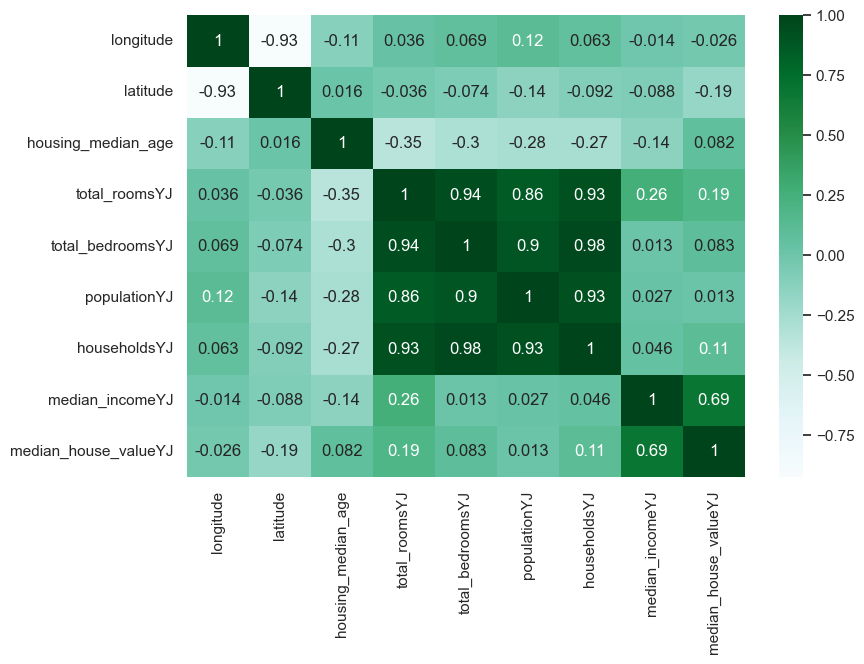

In [4]:
# NO DEBES MODIFICAR EL CóDIGO DE ESTA CELDA:

# Supongamos que obtenemos la matriz de correlación de Pearson, pero a las variables
# indicadas con YJ se les aplica ajuste de sesgo con Yeo-Johnson:
variables = ['longitude', 'latitude', 'housing_median_age', 'total_roomsYJ',
             'total_bedroomsYJ', 'populationYJ', 'householdsYJ', 'median_incomeYJ',
             'median_house_valueYJ']

# Creamos un nuevo DataFrame para almacenar las variables transformadas:
df_procesado = pd.DataFrame()

for var in variables:
    if var.endswith('YJ'):
        # Identificamos las variables del DataFrame origial a las cuales les aplicaremos Yeo-Johnson:
        col_origen = var if var in misdatos.columns else var[:-2]

        # Aplicamos la transformación Yeo-Johnson.
        # Usamos doble corchete ya que la función power_transform requiere un array 2D:
        df_procesado[var] = power_transform(misdatos[[col_origen]], method='yeo-johnson')
    else:
        # Las variables que no terminan en 'YJ' se copian directamente de los datos originales.
        df_procesado[var] = misdatos[var]

# Obtenemos la matriz de correlación de Pearson:
matriz_correlacion = df_procesado.corr(method='pearson')

sns.set(rc={'figure.figsize':(9,6)})
sns.heatmap(matriz_correlacion, annot=True, cmap='BuGn' )
plt.show()

**PREGUNTAS:**

*   **Pregunta 2.1.** ¿A qué tipo de variables (numéricas o categóricas) se aplica la matriz de correlación Pearson? ¿Y cuál es el objetivo de obtener dicha matriz?

*   **Pregunta 2.2.** Con respecto a la variable de salida, ¿qué variables de entrada están mayormente correlacionadas con ella? ¿Tiene sentido dentro del contexto y significado de las variables del problema?

*   **Pregunta 2.3.** En particular ¿cómo explicas el valor de correlación obtenido del factor "longitude" con respecto a la variable de salida transformada?

*   **Pregunta 2.4.** ¿Y cómo explicas el valor de correlación obtenido del factor "latitude" con respecto a la variable de salida transformada? ¿Tiene sentido con respecto al significado del problema?

*   **Pregunta 2.5.** Observa que con respecto a las variables de entrada y el concepto de multicolinealidad, varias de ellas tienen un alto valor de correlación de Pearson, ¿qué decisiones podemos tomar ahora con respecto a dichas variables?

### **Respuestas:**


++++++++ Inicia sección para agregar texto ++++++++++++++++++++++++


*   **Respuesta 2.1.** Se aplica a variables numéricas continuas y discretas. Su objetivo es medir la fuerza y dirección de una relación lineal entre dos variables del modelo. Nos ayuda a identificar la existencia de una relación lineal entre una variable de entrada y la variable objetivo, así como encontrar multicolinealidad entre distintas variables de entrada.

*   **Respuesta 2.2.** La variable que está más correlacionada con la objetivo (0.69) es: `median_incomeYJ`. Esto tendría sentido ya que al tener un mayor ingreso en cierta zona determinada, mayor el precio de las casas disponibles. Después de esta, las siguientes variables con mayor correlación son: `total_roomsYJ` (0.19) y `latitude` (-0.19), aunque ya podríamos decir que tienen correlación débil.

*   **Respuesta 2.3.** El valor es muy cercano a cero (-0.026). Esto indica que no hay relación lineal entre la longitud con el precio medio de las casas. Sin embargo, podría existir cierta relación si usamos un rango definido de latitud, que la correlación no capte.

*   **Respuesta 2.4.** El valor es de -0.19. Esto nos indica que mientras más al norte nos encontremos, el precio de las casas decrece ligeramente. Puede tener sentido aunque la correlación tampoco es tan fuerte, esto nos dice la existencia de zonas al norte que también pueden ser bastante costosas.

*   **Respuesta 2.5.** Se observa una fuerte correlación en: `total_rooms`, `total_bedrooms`, `population` y `households` ya que las 4 medidas están relacionadas con el tamaño de la manzana. Podríamos quedarnos con solo una de ellas para nuestro modelo, por ejemplo `population`. Otra estrategía sería combinarlas mediante un análisis de componentes principales.


++++++++ Termina sección para agregar texto ++++++++++++++++++++++++

# **Ejercicio - 3: Conclusiones Finales**

**En particular, cuando hayas usado algún LLM, comenta qué tanto cambiaste a personalizaste las respuestas. Por ejemplo: ¿usaste todo el texto que te proporcionó o solo algunas partes?; ¿complementaste con varios LLM para cada respuesta? ¿Le hiciste preguntas adicionales, después de la primera?**



++++++++ Incluye a continuación tus conclusiones finales de la actividad ++++++++++++++++++++++++++


En este conjunto de datos, preparar la información para una regresión lineal múltiple requiere varias decisiones distintas, las cuales normalmente forman parte de la ingeniería de características: corregir el sesgo de las variables de conteo (total_rooms, total_bedrooms, population, households) con Yeo-Johnson, escalar después de transformar, tratar las coordenadas como información espacial en lugar de variables sesgadas, resolver la multicolinealidad entre variables y atender la censura de la variable objetivo. La variable más informativa es median_income.

Para esta actividad utilicé Claude (Anthropic) como apoyo. Redacté mis propias respuestas con base a mis notas del curso de Ciencia y Analítica de Datos y le pedí al modelo Opus que me diera feedback. En los casos que me encontraba sin conocimiento previo le pedí la explicación de los conceptos con el fin de entender el tema antes de escribir mi respuesta.

++++++++ Termina sección para agregar texto ++++++++++++++++++++++++

# **<< Fin de la Actividad de la Semana 2 - California Housing>>**